In [1]:
!date

Thu Sep 17 20:57:07 PDT 2026


In [2]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [3]:
projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'
figdir = f'{projdir}/figures/pmds'
outdir = f'{projdir}/results/qc/data/qc15'
!mkdir -p {outdir}
classes = ['never', 'rare', 'variable', 'common', 'constitutive']

### replication timing / LADs vs domain map (mechanism)

In [4]:
freq = pd.read_csv(f'{projdir}/results/meth_bins/domain_frequency_10kb.tsv.gz', sep='\t')
rt = pd.read_csv(f'{projdir}/results/meth_bins/annotations/rt_lad_10kb.tsv.gz', sep='\t')
ann = pd.read_csv(f'{projdir}/results/qc/data/qc14/bin_annotation_variance_10kb.tsv.gz', sep='\t')
d = freq.merge(rt, on=['chrom', 'bin_start']).merge(
    ann[['chrom', 'bin_start', 'annot', 'v_between', 'v_within', 'r2_state', 'dist_const_kb']],
    on=['chrom', 'bin_start'], how='left')
d['lad'] = (d['lad_bp'] > 5000).astype(int)
d.shape

(263774, 22)

In [5]:
d.head()

,chrom,bin_start,n_donors,mean_meth,sd_meth,freq_pmd,freq_rel,freq_pmd_R941,freq_rel_R941,freq_pmd_R1041,...,class_rel,fibroblast_pmd,rt,lad_bp,annot,v_between,v_within,r2_state,dist_const_kb,lad
0,chr1,690000,200,0.6329,0.0621,0.0,0.000,0.0,0.0000,0.0,...,never,1,68.8771,0.0,gene body,0.00387,0.00165,NaN,1900.0,0
1,chr1,700000,200,0.6579,0.0722,0.0,0.005,0.0,0.0068,0.0,...,rare,0,68.3749,0.0,gene body,0.00531,0.00289,NaN,1890.0,0
2,chr1,710000,200,0.8713,0.0330,0.0,0.000,0.0,0.0000,0.0,...,never,0,67.6994,0.0,gene body,0.00110,0.00103,NaN,1880.0,0
3,chr1,720000,200,0.9155,0.0141,0.0,0.000,0.0,0.0000,0.0,...,never,0,66.9052,0.0,gene body,0.00020,0.00009,NaN,1870.0,0
4,chr1,730000,201,0.9352,0.0093,0.0,0.000,0.0,0.0000,0.0,...,never,0,66.0378,0.0,gene body,0.00009,0.00011,NaN,1860.0,0


In [6]:
t = d.groupby('class_pmd').agg(n=('rt', 'size'), rt_median=('rt', 'median'), frac_lad=('lad', 'mean'),
                               mean_mcg=('mean_meth', 'median')).reindex(classes)
t

,n,rt_median,frac_lad,mean_mcg
class_pmd,,,,
never,82248,72.9170,0.130629,0.82985
rare,39354,61.9266,0.324440,0.67620
variable,27957,50.3106,0.464428,0.63500
common,7312,46.0054,0.462391,0.61930
constitutive,106903,24.5489,0.605371,0.56300


In [7]:
print('spearman freq_pmd vs RT:', round(d[['freq_pmd', 'rt']].corr(method='spearman').iloc[0, 1], 3))
print('spearman mean_mCG vs RT:', round(d[['mean_meth', 'rt']].corr(method='spearman').iloc[0, 1], 3))
dec = d.assign(rt_dec=pd.qcut(d['rt'], 10, labels=False)).groupby('rt_dec').agg(
    rt=('rt', 'median'), frac_constitutive=('class_pmd', lambda x: (x == 'constitutive').mean()),
    mean_mcg=('mean_meth', 'mean'), frac_lad=('lad', 'mean'), v_between=('v_between', 'median'))
dec

spearman freq_pmd vs RT: -0.824
spearman mean_mCG vs RT: 0.515


,rt,frac_constitutive,mean_mcg,frac_lad,v_between
rt_dec,,,,,
0.0,9.19290,0.991584,0.545515,0.624863,0.00509
1.0,18.25930,0.932249,0.557467,0.582803,0.00487
2.0,28.45040,0.816204,0.581464,0.572696,0.00458
3.0,38.36720,0.566857,0.618077,0.522311,0.00416
4.0,47.16710,0.361427,0.646649,0.474409,0.00376
5.0,55.23325,0.206968,0.673093,0.411890,0.00318
6.0,62.62375,0.108546,0.703240,0.334812,0.00243
7.0,69.10570,0.048110,0.724954,0.239186,0.00179
8.0,74.56390,0.017592,0.742279,0.147938,0.00115


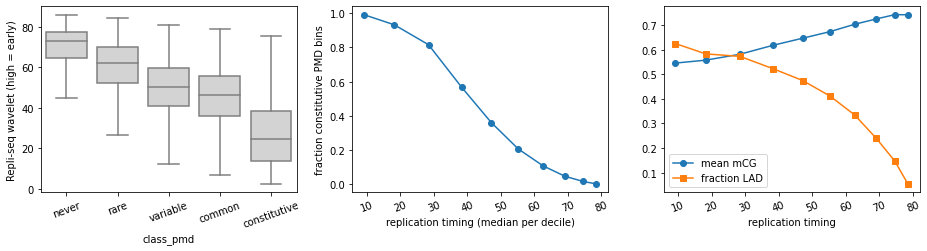

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
sns.boxplot(data=d, x='class_pmd', y='rt', order=classes, fliersize=0, ax=axes[0], color='lightgray')
axes[0].set_ylabel('Repli-seq wavelet (high = early)')
axes[1].plot(dec['rt'], dec['frac_constitutive'], 'o-')
axes[1].set_xlabel('replication timing (median per decile)'); axes[1].set_ylabel('fraction constitutive PMD bins')
axes[2].plot(dec['rt'], dec['mean_mcg'], 'o-', label='mean mCG')
axes[2].plot(dec['rt'], dec['frac_lad'], 's-', label='fraction LAD')
axes[2].set_xlabel('replication timing'); axes[2].legend()
for ax in axes: ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.savefig(f'{figdir}/qc15_rt_lad_vs_domains.png', dpi=150)

### variant density (assembly-vs-hg38) by domain class, before and after adjusting for RT

In [9]:
vd = pd.concat([pd.read_csv(f, sep='\t') for f in sorted(glob.glob(f'{projdir}/results/meth_bins/variant_density/chr*.bins.tsv.gz'))])
v = d.merge(vd.drop(columns=['n_donors_x'], errors='ignore'), on=['chrom', 'bin_start'], suffixes=('', '_vd'))
v['n_donors'] = v['n_donors_vd'] if 'n_donors_vd' in v else v['n_donors']
ncpg = pd.concat([pd.read_csv(f, sep='\t', usecols=['chrom', 'bin_start', 'n_cpg'])
                  for f in glob.glob(f'{projdir}/results/meth_bins/per_hap/HG00097_hap1.bins10kb.tsv.gz')])
v = v.merge(ncpg, on=['chrom', 'bin_start'], how='left')
for c in ['snv', 'indel', 'sv']:
    v[f'{c}_pd'] = v[c] / v['n_donors']
v['log_ncpg'] = np.log10(v['n_cpg'].fillna(0) + 1)
v.groupby('class_pmd')[['snv_pd', 'indel_pd', 'sv_pd']].median().reindex(classes).round(3)

,snv_pd,indel_pd,sv_pd
class_pmd,,,
never,11.124,3.164,0.0
rare,13.662,2.925,0.0
variable,13.841,2.755,0.0
common,13.401,2.708,0.0
constitutive,13.620,2.685,0.0


In [10]:
rows = []
for y in ['snv_pd', 'indel_pd', 'sv_pd']:
    x = v.dropna(subset=[y, 'rt', 'log_ncpg'])
    m0 = smf.ols(f'{y} ~ C(class_pmd)', x).fit()
    m1 = smf.ols(f'{y} ~ C(class_pmd) + log_ncpg + gene_bp', x) if 'gene_bp' in x else None
    m2 = smf.ols(f'{y} ~ C(class_pmd) + log_ncpg + rt', x).fit()
    m3 = smf.ols(f'{y} ~ rt + log_ncpg', x).fit()
    rows.append({'metric': y, 'r2_class': m0.rsquared, 'r2_class_cpg_rt': m2.rsquared, 'r2_rt_cpg': m3.rsquared,
                 'coef_constitutive_unadj': m0.params.get('C(class_pmd)[T.constitutive]', np.nan),
                 'coef_constitutive_rt_adj': m2.params.get('C(class_pmd)[T.constitutive]', np.nan)})
vt = pd.DataFrame(rows)
vt

,metric,r2_class,r2_class_cpg_rt,r2_rt_cpg,coef_constitutive_unadj,coef_constitutive_rt_adj
0,snv_pd,0.018600,0.041746,0.028294,0.406404,0.265796
1,indel_pd,0.010993,0.036395,0.034956,-0.056801,0.001464
2,sv_pd,0.002282,0.024132,0.023447,-0.021893,-0.022472


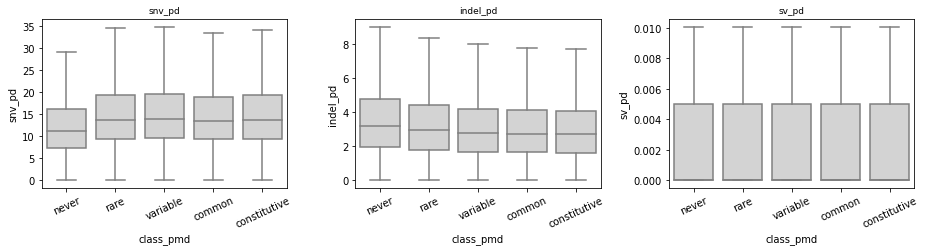

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, y in zip(axes, ['snv_pd', 'indel_pd', 'sv_pd']):
    sns.boxplot(data=v, x='class_pmd', y=y, order=classes, fliersize=0, showfliers=False, ax=ax, color='lightgray')
    ax.set_title(y, fontsize=9); ax.tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.savefig(f'{figdir}/qc15_variant_density_by_class.png', dpi=150)

### solo-WCGW mitotic clock

In [12]:
sw = pd.concat([pd.read_csv(f, sep='\t') for f in glob.glob(f'{projdir}/results/meth_bins/solo_wcgw/per_hap/*.tsv')])
sw_w = sw.pivot_table(index=['sample', 'hap'], columns=['site_set', 'class_pmd'], values='mean_mcg')
sw_w.columns = [f'{a}_{b}' for a, b in sw_w.columns]
sw_w = sw_w.reset_index()
sw_w['solo_depth'] = sw_w['solo_never'] - sw_w['solo_constitutive']
sw_w['all_depth'] = sw_w['all_never'] - sw_w['all_constitutive']
print(len(sw_w), 'haplotypes')
sw_w[['solo_constitutive', 'all_constitutive', 'solo_never', 'all_never', 'solo_depth', 'all_depth']].describe().round(2)

402 haplotypes


,solo_constitutive,all_constitutive,solo_never,all_never,solo_depth,all_depth
count,402.00,402.00,402.00,402.00,402.00,402.00
mean,32.97,56.82,70.21,73.25,37.24,16.44
std,6.39,6.16,3.07,2.03,4.03,4.38
min,5.38,20.93,53.86,62.38,24.67,6.62
25%,28.66,53.36,68.47,72.18,34.05,13.35
50%,32.99,57.27,70.23,73.32,37.27,16.16
75%,37.25,61.16,72.34,74.44,39.81,18.80
max,48.73,69.22,79.63,78.66,49.59,41.45


corr(all_depth, solo_depth): 0.947
CV all: 0.108  CV solo: 0.194


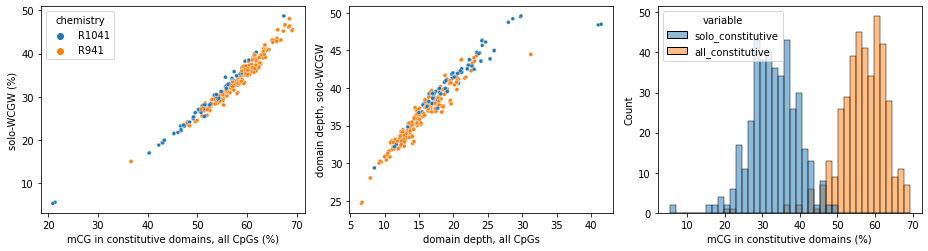

In [13]:
chem = pd.read_csv(f'{projdir}/results/qc/data/supp_seq_qc.csv').set_index('sample_id')['sequencing_chemistry_ont']
sw_w['chemistry'] = sw_w['sample'].map(chem)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
sns.scatterplot(data=sw_w, x='all_constitutive', y='solo_constitutive', hue='chemistry', s=14, ax=axes[0])
axes[0].set_xlabel('mCG in constitutive domains, all CpGs (%)'); axes[0].set_ylabel('solo-WCGW (%)')
sns.scatterplot(data=sw_w, x='all_depth', y='solo_depth', hue='chemistry', s=14, ax=axes[1], legend=False)
axes[1].set_xlabel('domain depth, all CpGs'); axes[1].set_ylabel('domain depth, solo-WCGW')
sns.histplot(data=sw_w.melt(id_vars='chemistry', value_vars=['solo_constitutive', 'all_constitutive']),
             x='value', hue='variable', bins=40, ax=axes[2])
axes[2].set_xlabel('mCG in constitutive domains (%)')
plt.tight_layout(); plt.savefig(f'{figdir}/qc15_solo_wcgw.png', dpi=150)
print('corr(all_depth, solo_depth):', round(sw_w[['all_depth', 'solo_depth']].corr().iloc[0, 1], 3))
print('CV all:', round(sw_w['all_constitutive'].std() / sw_w['all_constitutive'].mean(), 3),
      ' CV solo:', round(sw_w['solo_constitutive'].std() / sw_w['solo_constitutive'].mean(), 3))

In [14]:
for y in ['all_constitutive', 'solo_constitutive', 'all_depth', 'solo_depth']:
    m = smf.ols(f'{y} ~ C(chemistry)', sw_w.dropna(subset=['chemistry'])).fit()
    print(f'{y}: chemistry R2 {m.rsquared:.3f}')

all_constitutive: chemistry R2 0.206
solo_constitutive: chemistry R2 0.146
all_depth: chemistry R2 0.169
solo_depth: chemistry R2 0.217


### residual outside-domain axis vs clonality (XIST) and RNA state

In [15]:
z = np.load(f'{projdir}/results/meth_bins/donor_bin_meth_10kb.npz', allow_pickle=True)
meth, donors = z['meth'], list(z['donors'])
dm = pd.read_csv(f'{projdir}/results/qc/data/qc13/donor_pmd_expansion_metrics.tsv', sep='\t').set_index('sample').loc[donors].reset_index()
idx_never = np.flatnonzero(freq['class_pmd'].values == 'never')
X = np.column_stack([np.ones(len(donors)), dm['depth_constitutive'], (dm['chemistry'] == 'R1041').astype(float)])
Y = meth[:, idx_never]
ok = ~np.isnan(Y).any(axis=0)
Y = Y[:, ok]
beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
R = Y - X @ beta
u, s, vt_ = np.linalg.svd(R - R.mean(axis=0), full_matrices=False)
var = s ** 2 / (s ** 2).sum()
pcs = pd.DataFrame(u[:, :5] * s[:5], columns=[f'rPC{i+1}' for i in range(5)])
pcs['sample'] = donors
print('residual variance explained:', var[:5].round(3))

residual variance explained: [0.275 0.102 0.062 0.036 0.02 ]


In [16]:
xist = pd.read_csv(f'{projdir}/results/qc/data/xist_promoter_skew.tsv', sep='\t')
rna = pd.read_csv(f'{projdir}/results/qc/data/rna_markers_wide.tsv', sep='\t')
sets = {'proliferation': ['MKI67', 'TOP2A', 'PCNA', 'CCNB1', 'AURKB'],
        'plasmablast': ['PRDM1', 'XBP1', 'IRF4', 'CD38'],
        'naive_memory_B': ['TCL1A', 'CD27', 'MS4A1', 'CD19', 'CR2'],
        'activation': ['CD40', 'NFKB1', 'TRAF1', 'ICAM1']}
for k, g in sets.items():
    have = [x for x in g if x in rna.columns]
    rna[k] = np.log1p(rna[have]).mean(axis=1)
m = pcs.merge(dm, on='sample').merge(xist[['sample', 'skew', 'hap1_meth', 'hap2_meth']], on='sample', how='left').merge(
    rna[['sample'] + list(sets)], on='sample', how='left')
m.head()

,rPC1,rPC2,rPC3,rPC4,rPC5,sample,mcg_never,mcg_constitutive,mcg_variable,mcg_rare,...,id_prefix,collection,boundary_spread,skew,hap1_meth,hap2_meth,proliferation,plasmablast,naive_memory_B,activation
0,-2.936103,-0.232465,1.284731,0.150238,-0.719330,HG00097,0.778194,0.532610,0.603890,0.648395,...,HG,1000G,-0.051597,0.471476,0.714926,0.243450,5.021750,5.108714,5.756772,5.598790
1,-0.964943,-1.748497,1.414189,1.489781,0.161143,HG00099,0.789830,0.591849,0.659184,0.688841,...,HG,1000G,NaN,0.781786,0.878638,0.096852,4.486836,5.378894,5.597007,5.651680
2,1.356881,-2.477943,0.185736,0.221054,-0.040853,HG00126,0.782072,0.593786,0.653631,0.682833,...,HG,1000G,NaN,NaN,NaN,NaN,4.846538,4.983136,5.568247,5.669490
3,-5.918454,-1.813294,1.393471,-0.685140,-1.874661,HG00128,0.788791,0.552431,0.626630,0.666893,...,HG,1000G,NaN,0.455455,0.250529,0.705984,4.504706,5.365336,5.556881,6.097201
4,-0.942166,0.040806,1.076750,0.088117,-0.427802,HG00133,0.787096,0.585918,0.652731,0.686317,...,HG,1000G,NaN,0.273500,0.399449,0.672949,5.003439,4.889627,5.683683,5.654926


In [17]:
rows = []
for p in [f'rPC{i+1}' for i in range(5)] + ['depth_constitutive', 'mcg_never']:
    for c in ['skew'] + list(sets):
        x = m.dropna(subset=[p, c])
        if len(x) < 20:
            continue
        r = smf.ols(f'{p} ~ {c}', x).fit()
        rows.append({'y': p, 'covariate': c, 'n': len(x), 'r2': r.rsquared, 'p': r.f_pvalue})
res = pd.DataFrame(rows)
res.pivot(index='covariate', columns='y', values='r2').round(3)

y,depth_constitutive,mcg_never,rPC1,rPC2,rPC3,rPC4,rPC5
covariate,,,,,,,
activation,0.020,0.025,0.014,0.053,0.007,0.027,0.011
naive_memory_B,0.000,0.006,0.019,0.006,0.002,0.001,0.052
plasmablast,0.007,0.000,0.010,0.033,0.020,0.016,0.123
proliferation,0.019,0.035,0.023,0.038,0.000,0.002,0.019
skew,0.000,0.003,0.001,0.004,0.026,0.024,0.041


In [18]:
res.pivot(index='covariate', columns='y', values='p').round(4)

y,depth_constitutive,mcg_never,rPC1,rPC2,rPC3,rPC4,rPC5
covariate,,,,,,,
activation,0.0453,0.0251,0.0933,0.0011,0.2408,0.0218,0.1425
naive_memory_B,0.8375,0.2634,0.0560,0.2649,0.5353,0.6190,0.0013
plasmablast,0.2548,0.8961,0.1681,0.0112,0.0478,0.0781,0.0000
proliferation,0.0534,0.0082,0.0339,0.0062,0.8372,0.5793,0.0512
skew,0.9188,0.6212,0.7692,0.5468,0.1159,0.1354,0.0465


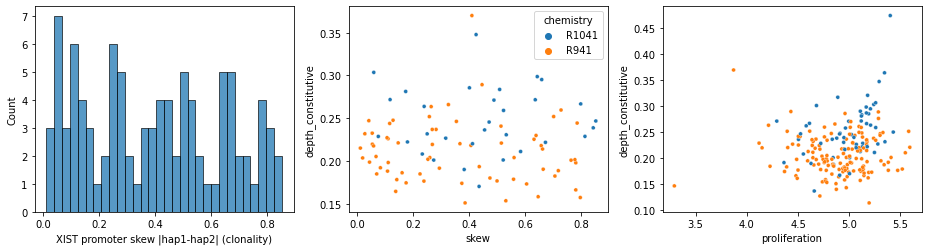

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
sns.histplot(data=m.dropna(subset=['skew']), x='skew', bins=30, ax=axes[0])
axes[0].set_xlabel('XIST promoter skew |hap1-hap2| (clonality)')
sns.scatterplot(data=m, x='skew', y='depth_constitutive', hue='chemistry', s=16, ax=axes[1])
sns.scatterplot(data=m, x='proliferation', y='depth_constitutive', hue='chemistry', s=16, ax=axes[2], legend=False)
plt.tight_layout(); plt.savefig(f'{figdir}/qc15_clonality_rna_vs_domains.png', dpi=150)

### write outputs

In [20]:
t.to_csv(f'{outdir}/rt_lad_by_domain_class.tsv', sep='\t')
dec.to_csv(f'{outdir}/domains_by_rt_decile.tsv', sep='\t')
vt.to_csv(f'{outdir}/variant_density_models.tsv', sep='\t', index=False)
v.groupby('class_pmd')[['snv_pd', 'indel_pd', 'sv_pd']].median().reindex(classes).to_csv(f'{outdir}/variant_density_by_class.tsv', sep='\t')
sw_w.to_csv(f'{outdir}/solo_wcgw_per_hap.tsv', sep='\t', index=False)
res.to_csv(f'{outdir}/residual_axis_vs_clonality_rna.tsv', sep='\t', index=False)
m.to_csv(f'{outdir}/donor_residual_pcs_with_covariates.tsv', sep='\t', index=False)

In [21]:
!date

Thu Sep 17 20:57:34 PDT 2026
